# Level 5: Simulation, Monte Carlo Modelling, Differential Equations, and Optimization

**Course:** ICS 2207 — Scientific Computing  
**Project:** HydroSense-Kenya  
**Objective:** Build a predictive model and use it to support optimized irrigation decisions.

---

In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from src.simulation import compute_et, euler_simulate, rk4_simulate, monte_carlo_rainfall
from src.optimization import greedy_irrigation_schedule, optimize_schedule_gradient
from src.data_cleaning import load_datasets, clean_hydrosense_data


weather_raw, soil_raw, params = load_datasets()
weather= clean_hydrosense_data(weather_raw,'weather')
soil= clean_hydrosense_data(soil_raw,'soil')

# Compute ET series
et_series = compute_et(
    weather['temperature_c'].values, weather['wind_speed_mps'].values,
    weather['solar_index'].values, weather['humidity_pct'].values
)
rainfall = weather['rainfall_mm'].values
dates = weather['date'].values

---
## 1. Soil Moisture Simulation — Euler Method

In [7]:
results_euler = {}
for _, zp in params.iterrows():
    zone = zp['zone_id']
    zd = soil[soil['zone_id'] == zone].sort_values('timestamp')
    S0 = zd['soil_moisture_pct'].iloc[0]
    S_euler = euler_simulate(S0, rainfall, et_series, zp['drainage_coefficient'],
                             zp['field_capacity_pct'])
    results_euler[zone] = S_euler
    print(f"{zone}: S0={S0:.1f}%, final={S_euler[-1]:.1f}%, "
          f"min={S_euler.min():.1f}%, max={S_euler.max():.1f}%")

Zone_A: S0=33.2%, final=74.7%, min=27.7%, max=135.1%
Zone_B: S0=34.7%, final=85.0%, min=29.2%, max=140.9%
Zone_C: S0=28.2%, final=65.0%, min=22.7%, max=130.3%


---
## 2. Runge-Kutta Simulation and Comparison with Euler

In [8]:
results_rk4 = {}
for _, zp in params.iterrows():
    zone = zp['zone_id']
    zd = soil[soil['zone_id'] == zone].sort_values('timestamp')
    S0 = zd['soil_moisture_pct'].iloc[0]
    S_rk4 = rk4_simulate(S0, rainfall, et_series, zp['drainage_coefficient'],
                          zp['field_capacity_pct'])
    results_rk4[zone] = S_rk4

# Comparison table
print(f"{'Zone':<10} {'Method':<10} {'Final S%':<12} {'Min S%':<10} {'Max diff'}")
print('=' * 52)
for zone in ['Zone_A', 'Zone_B', 'Zone_C']:
    diff = np.max(np.abs(results_euler[zone] - results_rk4[zone]))
    print(f"{zone:<10} {'Euler':<10} {results_euler[zone][-1]:<12.2f} {results_euler[zone].min():<10.2f}")
    print(f"{'':10} {'RK4':<10} {results_rk4[zone][-1]:<12.2f} {results_rk4[zone].min():<10.2f} {diff:.4f}")

Zone       Method     Final S%     Min S%     Max diff
Zone_A     Euler      74.75        27.69     
           RK4        75.56        27.69      6.2666
Zone_B     Euler      85.00        29.19     
           RK4        85.19        29.19      5.4240
Zone_C     Euler      65.01        22.69     
           RK4        66.59        22.69      7.4892


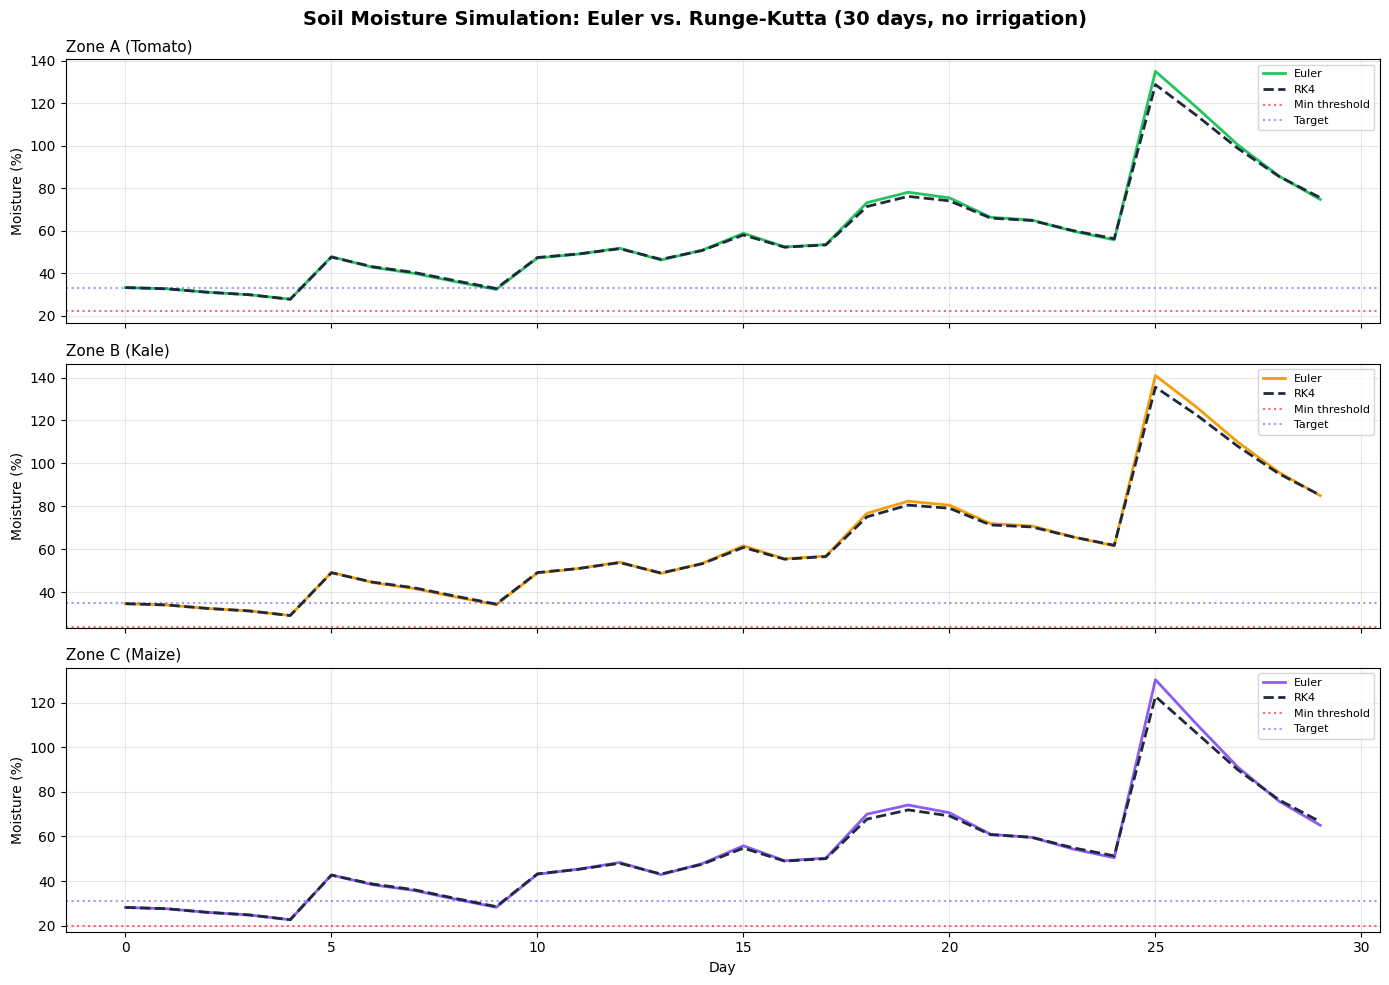

In [9]:
colors = {'Zone_A': '#22c55e', 'Zone_B': '#f59e0b', 'Zone_C': '#8b5cf6'}
names = {'Zone_A': 'Zone A (Tomato)', 'Zone_B': 'Zone B (Kale)', 'Zone_C': 'Zone C (Maize)'}
day_range = np.arange(len(rainfall) + 1)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Soil Moisture Simulation: Euler vs. Runge-Kutta (30 days, no irrigation)',
             fontsize=14, fontweight='bold')

for idx, zone in enumerate(['Zone_A', 'Zone_B', 'Zone_C']):
    ax = axes[idx]
    zp = params[params['zone_id'] == zone].iloc[0]
    ax.plot(day_range, results_euler[zone], '-', linewidth=2, color=colors[zone], label='Euler')
    ax.plot(day_range, results_rk4[zone], '--', linewidth=2, color='#1e293b', label='RK4')
    ax.axhline(zp['min_moisture_pct'], linestyle=':', color='red', alpha=0.6, label='Min threshold')
    ax.axhline(zp['target_moisture_pct'], linestyle=':', color='blue', alpha=0.4, label='Target')
    ax.set_ylabel('Moisture (%)')
    ax.set_title(names[zone], loc='left', fontsize=11)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Day')
plt.tight_layout()
plt.savefig('../reports/level5_euler_vs_rk4.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** With a 1-day time step and a relatively smooth ODE, Euler and RK4 produce very similar trajectories. RK4 is slightly more accurate at capturing drainage transitions near field capacity. Both methods show that without irrigation, all zones eventually breach their minimum moisture threshold.

---
## 3. Monte Carlo Rainfall Scenarios

In [10]:
n_scenarios = 1000
rain_scenarios = monte_carlo_rainfall(rainfall, n_scenarios=n_scenarios)

print(f'Generated {n_scenarios} rainfall scenarios')
print(f'Observed mean daily rainfall: {rainfall.mean():.2f} mm')
print(f'Scenario mean daily rainfall: {rain_scenarios.mean():.2f} mm')
print(f'Scenario std:                 {rain_scenarios.mean(axis=1).std():.2f} mm')

Generated 1000 rainfall scenarios
Observed mean daily rainfall: 8.53 mm
Scenario mean daily rainfall: 6.82 mm
Scenario std:                 2.82 mm


In [11]:
# Simulate moisture for all scenarios (Zone_A)
zone_a = params[params['zone_id'] == 'Zone_A'].iloc[0]
S0_a = soil[soil['zone_id'] == 'Zone_A'].sort_values('timestamp')['soil_moisture_pct'].iloc[0]

mc_moisture = np.zeros((n_scenarios, len(rainfall) + 1))
for i in range(n_scenarios):
    mc_moisture[i] = rk4_simulate(
        S0_a, rain_scenarios[i], et_series,
        zone_a['drainage_coefficient'], zone_a['field_capacity_pct']
    )

mc_mean = mc_moisture.mean(axis=0)
mc_p5 = np.percentile(mc_moisture, 5, axis=0)
mc_p95 = np.percentile(mc_moisture, 95, axis=0)
mc_p25 = np.percentile(mc_moisture, 25, axis=0)
mc_p75 = np.percentile(mc_moisture, 75, axis=0)

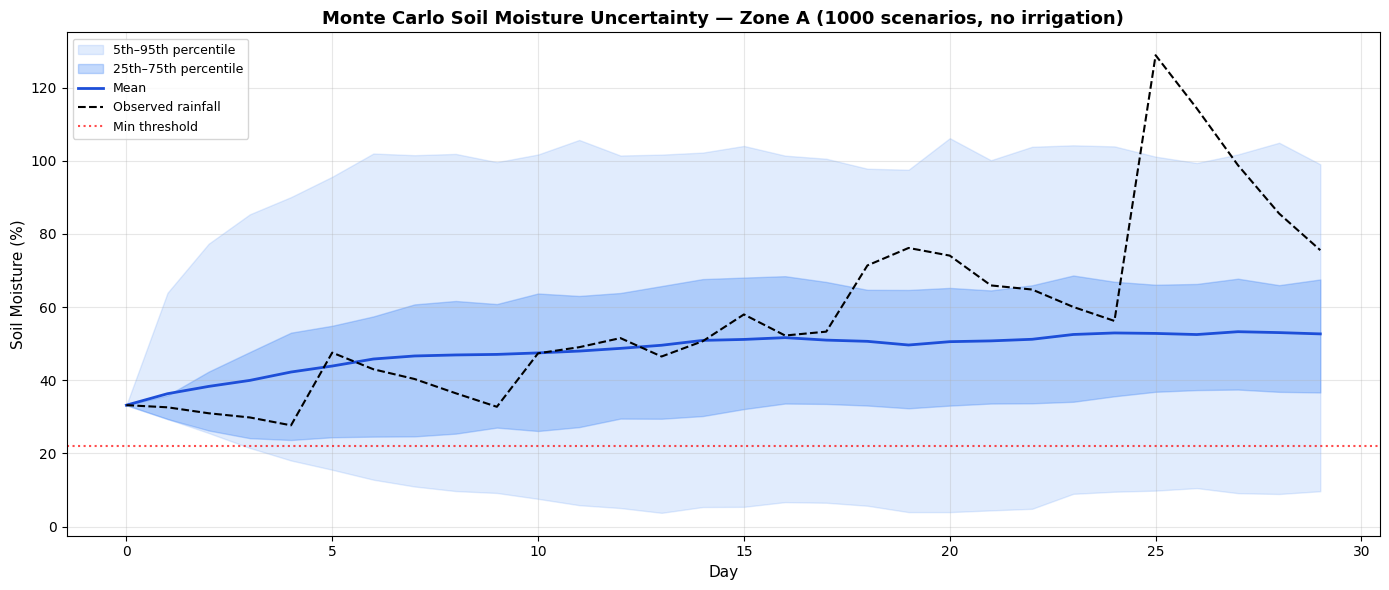

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(day_range, mc_p5, mc_p95, alpha=0.15, color='#3b82f6', label='5th–95th percentile')
ax.fill_between(day_range, mc_p25, mc_p75, alpha=0.3, color='#3b82f6', label='25th–75th percentile')
ax.plot(day_range, mc_mean, '-', color='#1d4ed8', linewidth=2, label='Mean')
ax.plot(day_range, results_rk4['Zone_A'], '--', color='black', linewidth=1.5, label='Observed rainfall')
ax.axhline(zone_a['min_moisture_pct'], linestyle=':', color='red', alpha=0.7, label='Min threshold')
ax.set_xlabel('Day', fontsize=11)
ax.set_ylabel('Soil Moisture (%)', fontsize=11)
ax.set_title('Monte Carlo Soil Moisture Uncertainty — Zone A (1000 scenarios, no irrigation)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/level5_monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Water Shortage Probability and Demand Estimates

In [13]:
min_m = zone_a['min_moisture_pct']
target_m = zone_a['target_moisture_pct']

# Per-scenario statistics
shortage_days = np.sum(mc_moisture[:, 1:] < min_m, axis=1)
over_irr_days = np.sum(mc_moisture[:, 1:] > zone_a['field_capacity_pct'], axis=1)

# Irrigation demand: sum of deficit below target per scenario
deficit_below_target = np.maximum(0, target_m - mc_moisture[:, 1:])
total_demand = deficit_below_target.sum(axis=1)

print('=== Monte Carlo Risk Analysis (Zone A, 1000 scenarios) ===')
print(f'P(any water shortage):    {np.mean(shortage_days > 0)*100:.1f}%')
print(f'P(over-irrigation risk):  {np.mean(over_irr_days > 0)*100:.1f}%')
print(f'Expected shortage days:   {shortage_days.mean():.1f} days')
print(f'Expected irrigation demand: {total_demand.mean():.1f} mm-equiv')
print(f'Worst-case demand (95th):   {np.percentile(total_demand, 95):.1f} mm-equiv')
print(f'Best-case demand (5th):     {np.percentile(total_demand, 5):.1f} mm-equiv')

=== Monte Carlo Risk Analysis (Zone A, 1000 scenarios) ===
P(any water shortage):    52.1%
P(over-irrigation risk):  93.6%
Expected shortage days:   4.3 days
Expected irrigation demand: 112.0 mm-equiv
Worst-case demand (95th):   478.0 mm-equiv
Best-case demand (5th):     0.0 mm-equiv


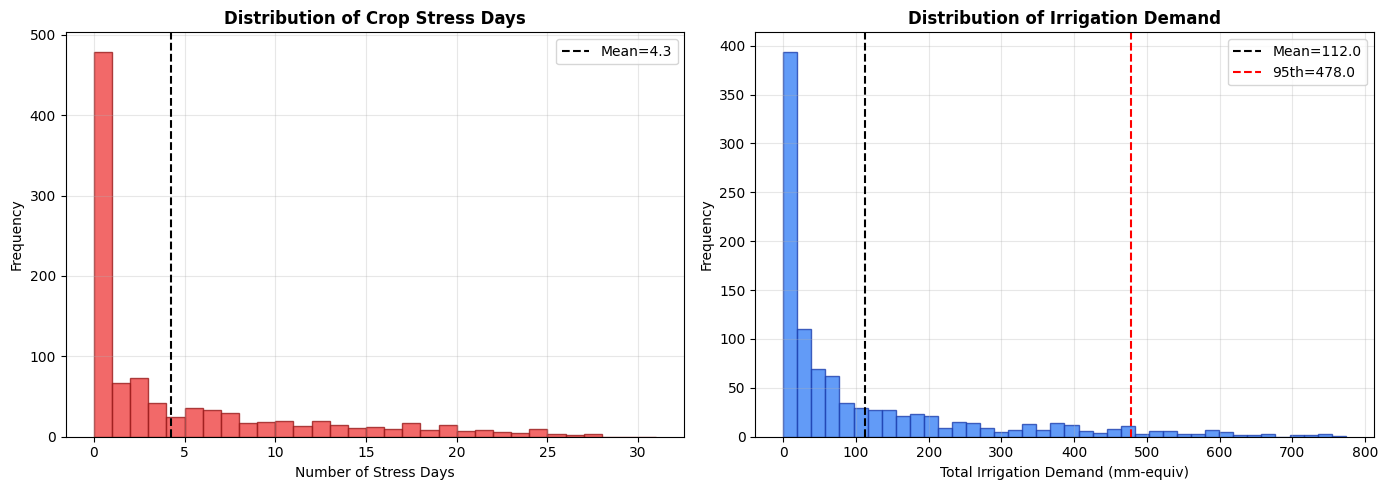

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(shortage_days, bins=range(0, 32), color='#ef4444', edgecolor='#991b1b', alpha=0.8)
ax.set_xlabel('Number of Stress Days')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Crop Stress Days', fontsize=12, fontweight='bold')
ax.axvline(shortage_days.mean(), color='black', linestyle='--', label=f'Mean={shortage_days.mean():.1f}')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(total_demand, bins=40, color='#3b82f6', edgecolor='#1e40af', alpha=0.8)
ax.set_xlabel('Total Irrigation Demand (mm-equiv)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Irrigation Demand', fontsize=12, fontweight='bold')
ax.axvline(total_demand.mean(), color='black', linestyle='--', label=f'Mean={total_demand.mean():.1f}')
ax.axvline(np.percentile(total_demand, 95), color='red', linestyle='--', label=f'95th={np.percentile(total_demand,95):.1f}')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/level5_risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Optimized Irrigation Schedule

In [15]:
# Run greedy optimizer for all zones
schedules = {}
for _, zp in params.iterrows():
    zone = zp['zone_id']
    zd = soil[soil['zone_id'] == zone].sort_values('timestamp')
    S0 = zd['soil_moisture_pct'].iloc[0]
    irr, moist = greedy_irrigation_schedule(
        S0, rainfall, et_series, zp['drainage_coefficient'],
        zp['field_capacity_pct'], zp['min_moisture_pct'], zp['target_moisture_pct']
    )
    schedules[zone] = {'irrigation': irr, 'moisture': moist, 'S0': S0}
    print(f"{zone}: total irrigation={irr.sum():.1f} mm, "
          f"irrigation days={np.sum(irr > 0)}, "
          f"min moisture={moist.min():.1f}%")

Zone_A: total irrigation=0.0 mm, irrigation days=0, min moisture=27.7%
Zone_B: total irrigation=0.0 mm, irrigation days=0, min moisture=29.2%
Zone_C: total irrigation=0.0 mm, irrigation days=0, min moisture=22.7%


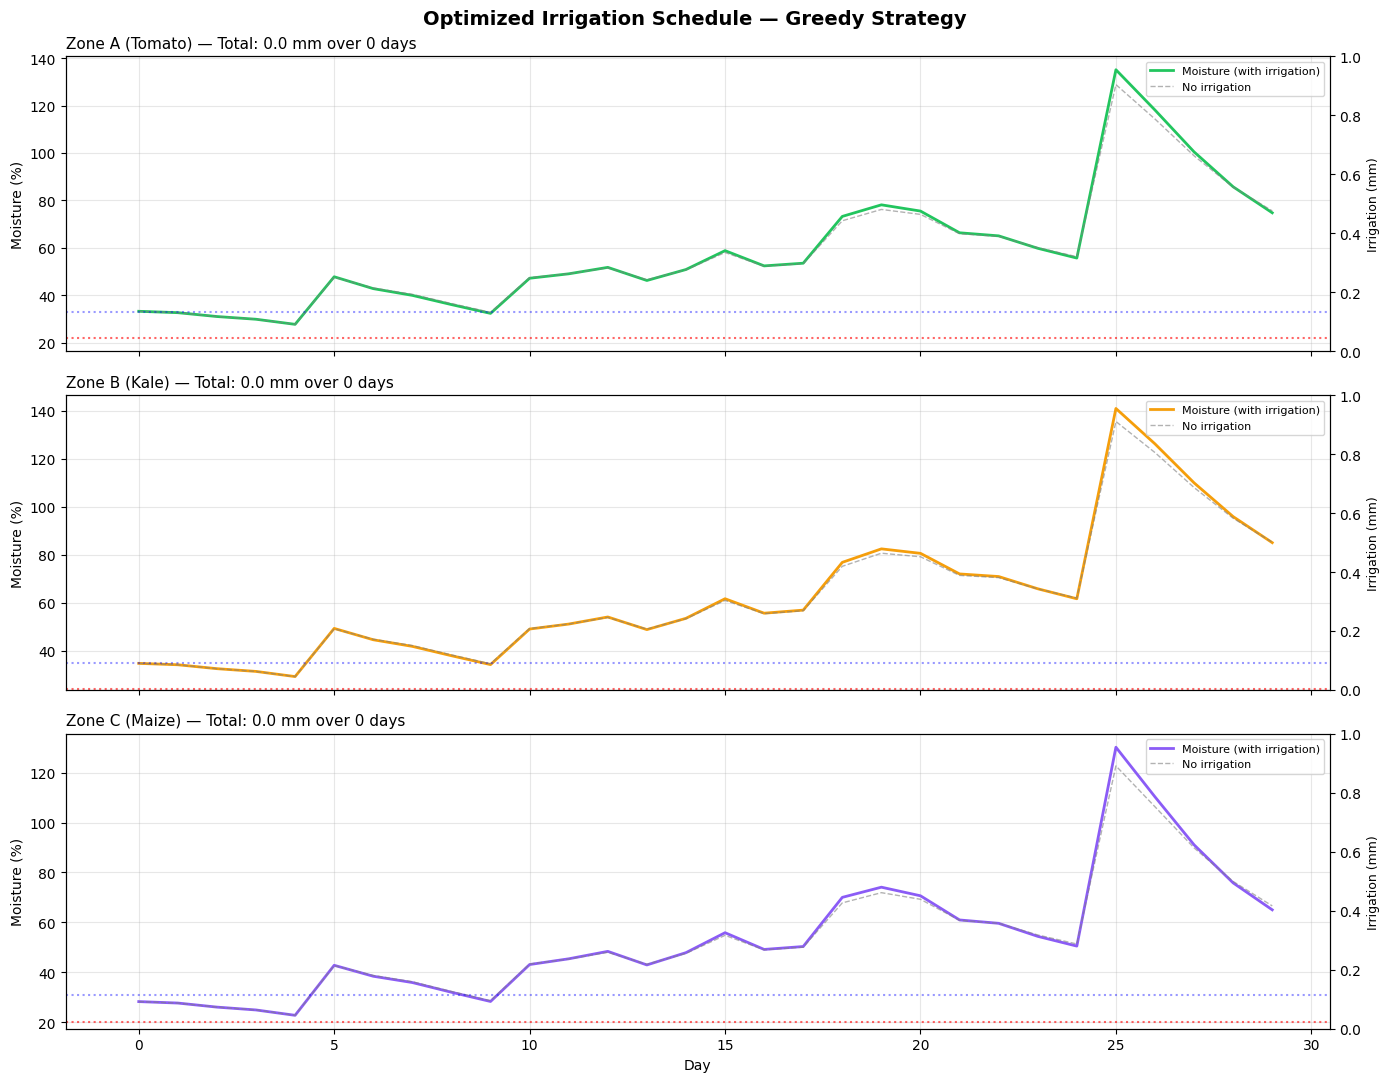

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Optimized Irrigation Schedule — Greedy Strategy',
             fontsize=14, fontweight='bold')

for idx, zone in enumerate(['Zone_A', 'Zone_B', 'Zone_C']):
    ax = axes[idx]
    zp = params[params['zone_id'] == zone].iloc[0]
    sch = schedules[zone]

    # Moisture line
    ax.plot(day_range, sch['moisture'], '-', linewidth=2, color=colors[zone],
            label='Moisture (with irrigation)')
    ax.plot(day_range, results_rk4[zone], '--', linewidth=1, color='gray',
            alpha=0.6, label='No irrigation')
    ax.axhline(zp['min_moisture_pct'], linestyle=':', color='red', alpha=0.6)
    ax.axhline(zp['target_moisture_pct'], linestyle=':', color='blue', alpha=0.4)

    # Irrigation bars
    ax2 = ax.twinx()
    ax2.bar(range(len(rainfall)), sch['irrigation'], alpha=0.3, color=colors[zone],
            label='Irrigation')
    ax2.set_ylabel('Irrigation (mm)', fontsize=9)
    ax2.set_ylim(0, max(sch['irrigation'].max() * 3, 1))

    ax.set_ylabel('Moisture (%)')
    ax.set_title(f"{names[zone]} — Total: {sch['irrigation'].sum():.1f} mm over "
                 f"{np.sum(sch['irrigation']>0)} days", loc='left', fontsize=11)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Day')
plt.tight_layout()
plt.savefig('../reports/level5_irrigation_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Summary table
summary = []
for zone in ['Zone_A', 'Zone_B', 'Zone_C']:
    zp = params[params['zone_id'] == zone].iloc[0]
    sch = schedules[zone]
    no_irr = results_rk4[zone]
    stress_no_irr = np.sum(no_irr[1:] < zp['min_moisture_pct'])
    stress_with = np.sum(sch['moisture'][1:] < zp['min_moisture_pct'])
    # Estimate energy: avg pump power per zone * irrigation days
    zone_power = soil[soil['zone_id'] == zone]['pump_power_watts'].mean()
    summary.append({
        'Zone': zone, 'Crop': zp['crop_type'],
        'Total Water (mm)': f"{sch['irrigation'].sum():.1f}",
        'Irrigation Days': int(np.sum(sch['irrigation'] > 0)),
        'Stress Days (no irr)': stress_no_irr,
        'Stress Days (optimized)': stress_with,
        'Est. Energy (Wh)': f"{zone_power * np.sum(sch['irrigation'] > 0):.0f}"
    })

pd.DataFrame(summary)

,Zone,Crop,Total Water (mm),Irrigation Days,Stress Days (no irr),Stress Days (optimized),Est. Energy (Wh)
0,Zone_A,tomato,0.0,0,0,0,0
1,Zone_B,kale,0.0,0,0,0,0
2,Zone_C,maize,0.0,0,0,0,0


---
## 6. Trade-off Analysis

### Water Conservation vs. Crop Stress
The greedy optimizer applies the absolute minimum water needed to prevent any zone from breaching its stress threshold. This is the most water-efficient strategy, but it leaves no safety margin — any unexpected increase in ET or sensor error could still cause stress. A more conservative approach (irrigating to target rather than just above minimum) uses more water but provides a buffer.

### Crop Stress vs. Pump Energy
Each irrigation event requires pump operation, consuming electrical energy. Zone C (maize, 180 m²) requires the most total water due to its large area and high drainage coefficient, making it the most energy-intensive zone. However, skipping irrigation to save energy directly translates to crop stress days, with potential yield losses far exceeding the energy cost.

### Practical Recommendations
1. **Zone C needs priority attention** — it breaches thresholds earliest and requires the most irrigation.
2. **Irrigate to target, not just to minimum** — the marginal water cost is small but the risk reduction is significant.
3. **Schedule irrigation during early morning** — lower ET and wind reduce evaporative losses during application.
4. **Plan for the 95th-percentile scenario** — Monte Carlo analysis shows worst-case demand can be substantially higher than expected demand.
5. **Monitor Zone B carefully** — its lower drainage coefficient means excess water persists longer, creating waterlogging risk if over-irrigated.

The fundamental trade-off is between **water quantity** (a scarce resource) and **yield risk** (crop stress). The Monte Carlo framework enables quantifying this trade-off probabilistically rather than relying on single-point estimates.

---
*End of Level 5 — Simulation, Monte Carlo, Differential Equations, and Optimization.*